<a href="https://colab.research.google.com/github/Kaiking28/ECON3916-Statistical-Machine-Learning/blob/main/HW2/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Manual DGP Simulation
import numpy as np
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [10]:

def calculate_mad(data):
    median = np.median(data)
    abs_deviations = np.abs(data - median)
    mad = np.median(abs_deviations)
    return mad

sd = np.std(latency_logs)
mad = calculate_mad(latency_logs)

print(f"Standard Deviation: {sd:.2f}")
print(f"MAD: {mad:.2f}")


Standard Deviation: 453.54
MAD: 8.00


Standard Deviation:

Uses squared deviations: (x - mean)²
Outliers are squared, creating massive values so these dominate the calculation even though they're only 2% of data
Result: SD = 453.54, suggesting high variability everywhere

MAD (Median Absolute Deviation):

Uses absolute deviations from median: |x - median|
Takes the median of deviations and the 20 outliers affect only the top 2% of the sorted deviations. The median sits in the 98% normal data region
Result: MAD = 8.00, properly reflecting variability compared to SD

In [11]:
def bayesian_audit(prior, sensitivity, specificity):
    true_positive = prior * sensitivity
    false_positive = (1 - prior) * (1 - specificity)
    return true_positive / (true_positive + false_positive)

sensitivity = 0.98
specificity = 0.98

posterior = bayesian_audit(0.50, sensitivity, specificity)
print(f"Bootcamp (Base Rate 50%)")
print(f"  P(Cheater | Flagged) = {posterior}")

posterior = bayesian_audit(0.05, sensitivity, specificity)
print(f"Econ Class (Base Rate 5%)")
print(f"  P(Cheater | Flagged) = {posterior}")

posterior = bayesian_audit(0.001, sensitivity, specificity)
print(f"Honors Seminar (Base Rate 0.1%)")
print(f"  P(Cheater | Flagged) = {posterior}")


Bootcamp (Base Rate 50%)
  P(Cheater | Flagged) = 0.98
Econ Class (Base Rate 5%)
  P(Cheater | Flagged) = 0.7205882352941175
Honors Seminar (Base Rate 0.1%)
  P(Cheater | Flagged) = 0.04675572519083965


In [12]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])
# Write the calculation loop...
chi_square = 0
for i in range(len(observed)):
    chi_square += (observed[i] - expected[i])**2 / expected[i]

if chi_square > 3.84:
    print(f"invalid expieriment engineering bias")

else:
    print(f"valid experiment")


valid experiment


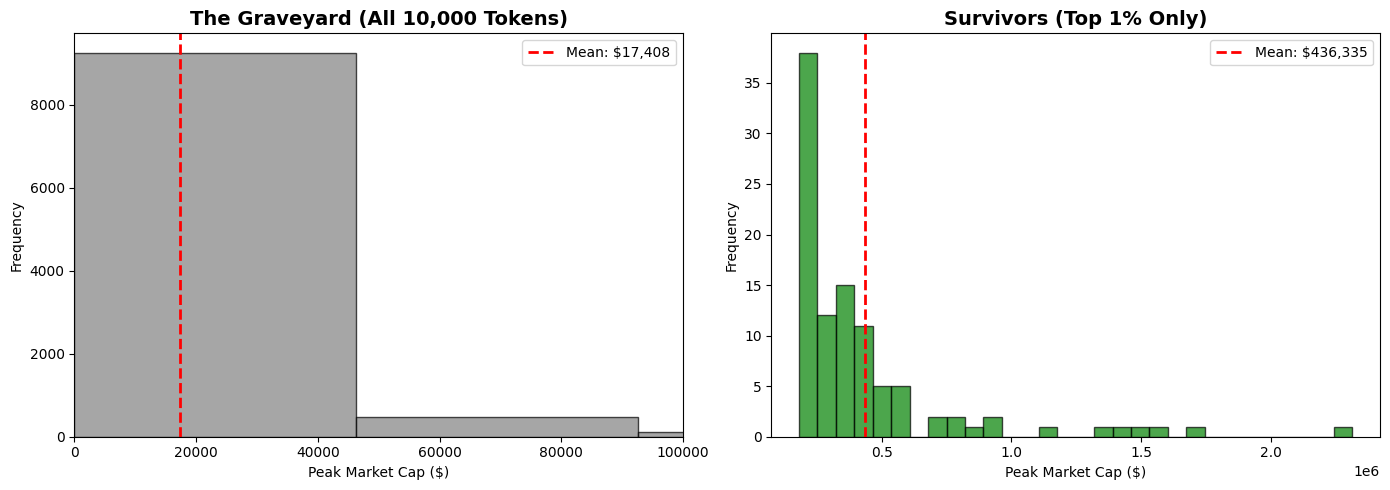

Total Tokens: 10000
Survivors (Top 1%): 100

Mean Market Cap (All Tokens): $17,408.42
Mean Market Cap (Survivors): $436,335.21

Survivorship Bias Multiplier: 25.1x

🚨 If you only study survivors, you overestimate success by 25.1x


In [13]:
#ai part


import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_tokens = 10000
peak_market_caps = np.random.pareto(a=1.5, size=n_tokens) * 10000

df_all = {'market_cap': peak_market_caps}
threshold = np.percentile(peak_market_caps, 99)
df_survivors = {'market_cap': peak_market_caps[peak_market_caps >= threshold]}

mean_all = np.mean(df_all['market_cap'])
mean_survivors = np.mean(df_survivors['market_cap'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df_all['market_cap'], bins=50, color='gray', alpha=0.7, edgecolor='black')
ax1.set_title('The Graveyard (All 10,000 Tokens)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Peak Market Cap ($)')
ax1.set_ylabel('Frequency')
ax1.axvline(mean_all, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_all:,.0f}')
ax1.legend()
ax1.set_xlim(0, 100000)

ax2.hist(df_survivors['market_cap'], bins=30, color='green', alpha=0.7, edgecolor='black')
ax2.set_title('Survivors (Top 1% Only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Peak Market Cap ($)')
ax2.set_ylabel('Frequency')
ax2.axvline(mean_survivors, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_survivors:,.0f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Total Tokens: {n_tokens}")
print(f"Survivors (Top 1%): {len(df_survivors['market_cap'])}")
print(f"\nMean Market Cap (All Tokens): ${mean_all:,.2f}")
print(f"Mean Market Cap (Survivors): ${mean_survivors:,.2f}")
print(f"\nSurvivorship Bias Multiplier: {mean_survivors/mean_all:.1f}x")
print(f"\n🚨 If you only study survivors, you overestimate success by {mean_survivors/mean_all:.1f}x")
